# Data and Preprocessing

This section prepares the dataset for all later models. The steps ensure that no data leakage occurs.

**1. Load dataset and separate features/target**
- Reads the CSV file into a DataFrame.
- `X` contains the 38 numerical features.
- `y` contains the binary PCR outcome.

**2. Train–test split (stratified)**
- Uses an 80/20 split.
- `stratify=y` preserves the severe class imbalance in both sets.
- Ensures fair evaluation and prevents optimistic bias.

**3. Feature scaling**
- Standardises features using `StandardScaler`.
- Fit is done **only on the training set** to avoid data leakage.
- The same transformation is applied to the test set.

**4. Class imbalance handling**
- Computes inverse‑frequency class weights.
- These weights are used later in logistic regression and SVM.
- Prints class proportions to show the imbalance explicitly.

This preprocessing pipeline ensures that all models are trained on clean, standardised, 
and correctly split data, consistent with the assessment requirements.


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
data = pd.read_csv("MSO2520_dataset.csv")


# Separate features and target
X = data.drop("Output_information", axis=1)
y = data["Output_information"]

print("Original shape:", X.shape)

print("Columns:", X.columns)

Original shape: (2597, 37)
Columns: Index(['ALT', 'AST', 'Albumin', 'ALP', 'Amilase', 'CK.MB', 'Direct_Bilirubin',
       'Glucose', 'Creatinine', 'Creatine.Kinase', 'LDH', 'eGFR', 'BASO',
       'ESO', 'HCT', 'HGB', 'LYM', 'MCH', 'MCHC', 'MCV', 'MONO', 'MPV', 'NEU',
       'PLT', 'RBC', 'RDW', 'WBC', 'CRP', 'D.Dimer', 'Ferritin', 'Fibrinogen',
       'INR', 'PT', 'Procalcitonin', 'ESR', 'Troponin', 'aPTT'],
      dtype='object')


## Train-Test Split

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

# Feature Scaling 
scaler = StandardScaler()

# Fit on training data only
X_train_scaled = scaler.fit_transform(X_train)

# Apply same transformation to test data
X_test_scaled = scaler.transform(X_test)

# Class Imbalance Handling
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, weights))
print("Class weights:", class_weight_dict)

# Show class proportions
print("Class distribution (overall):")
print(y.value_counts(normalize=True))

Train: (2077, 37)
Test: (520, 37)
Class weights: {np.float64(0.0): np.float64(0.5491803278688525), np.float64(1.0): np.float64(5.583333333333333)}
Class distribution (overall):
Output_information
0.0    0.910281
1.0    0.089719
Name: proportion, dtype: float64


# Exploratory Linear Algebra

This section analyses the geometric structure of the hematological dataset using core 
linear‑algebra tools. The goal is to understand correlations, intrinsic dimensionality, 
and dominant directions of variation before applying classification models.

**1. Covariance matrix**
- Computes the sample covariance matrix of the standardised features.
- Visualised as a heatmap to reveal collinearity and correlated feature groups.
- Strong blocks of correlation indicate reduced effective dimensionality.

**2. Eigenvalues and eigenvectors**
- Performs eigen‑decomposition of the covariance matrix.
- Sorts eigenvalues to analyse variance explained by each principal direction.
- Computes cumulative explained variance to assess intrinsic dimensionality.
- Produces a scree plot to visualise the eigenvalue spectrum.

**3. Principal Component Analysis (PCA)**
- Projects the data onto the first two principal components.
- Visualises PC1 vs PC2 to inspect structure, spread, and class separation.
- Helps identify whether linear boundaries may be effective.

**4. Outlier detection in PCA space**
- Computes distances from the median point in PC1–PC2 space.
- Flags the top 1% of distances as potential outliers.
- Visualises inliers vs outliers to understand their influence on classifiers.

These linear‑algebraic tools provide insight into the dataset’s geometry, 
informing the behaviour of logistic regression, KNN, and SVM in later sections.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Standardise Features

In [15]:
# Use scaled training data 
X_scaled = X_train_scaled
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Shape:", X_scaled_df.shape)
print("Number of features:", X_scaled_df.shape[1])

Shape: (2077, 37)
Number of features: 37


### Compute Covariance Matrix and Plot Heatmap

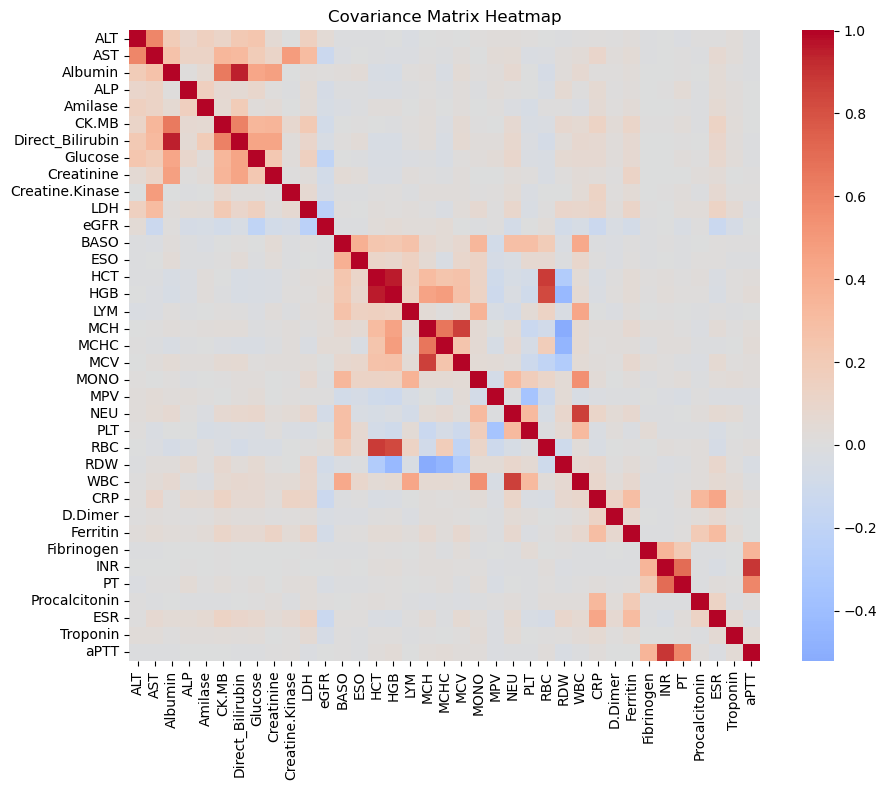

In [16]:
# Compute sample covariance matrix
cov_matrix = np.cov(X_scaled, rowvar=False)

# Convert to DataFrame for labelled heatmap
cov_df = pd.DataFrame(cov_matrix, index=X.columns, columns=X.columns)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cov_df,
    cmap="coolwarm",
    center=0,
    square=True,
)

plt.title("Covariance Matrix Heatmap")
plt.tight_layout()

plt.savefig("covariance_heatmap.png")
plt.show()

### Compute Eigenvalues and Generate Scree Plot

Variance explained by first 2 PCs: 19.79%
Variance explained by first 10 PCs: 59.59%
Variance explained by first 12 PCs: 65.41%


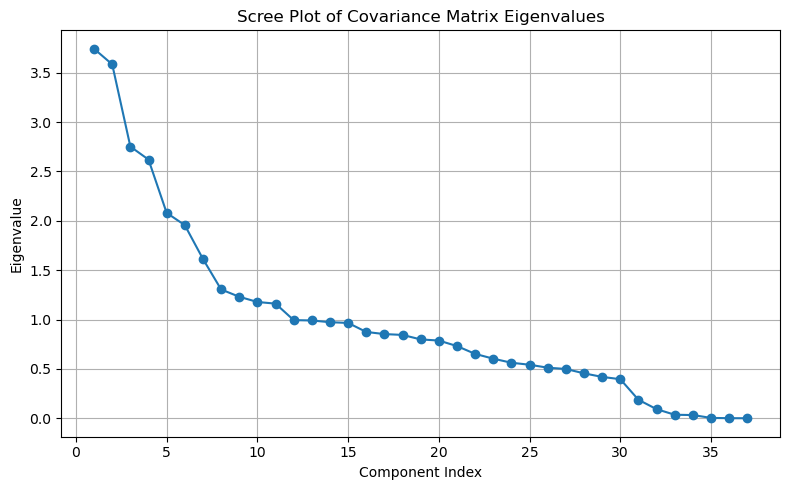

In [17]:
# Eigen-decomposition 
eigvals, eigvecs = np.linalg.eigh(cov_matrix)

# Sort in descending order
idx = np.argsort(eigvals)[::-1]
eigvals_sorted = eigvals[idx]
eigvecs_sorted = eigvecs[:, idx]

explained_variance_ratio = eigvals_sorted / eigvals_sorted.sum()
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

print(f"Variance explained by first 2 PCs: {100*cumulative_explained_variance[1]:.2f}%")
print(f"Variance explained by first 10 PCs: {100*cumulative_explained_variance[9]:.2f}%")
print(f"Variance explained by first 12 PCs: {100*cumulative_explained_variance[11]:.2f}%")

# Scree plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(eigvals_sorted) + 1), eigvals_sorted, marker="o")
plt.xlabel("Component Index")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot of Covariance Matrix Eigenvalues")
plt.grid(True)
plt.tight_layout()

plt.savefig("scree_plot.png")
plt.show()

### Perform PCA and Plot PC1 vs PC2

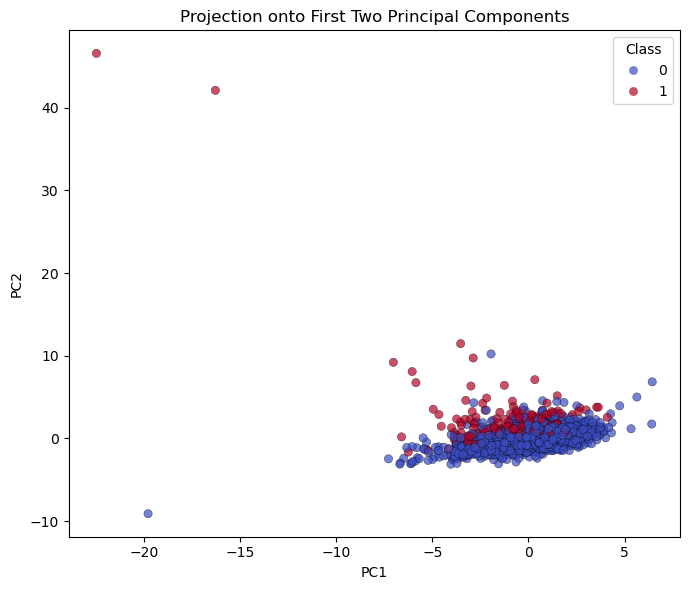

In [18]:
pca = PCA(n_components=10)
Z_train = pca.fit_transform(X_train_scaled)
Z_test = pca.transform(X_test_scaled)

pc1 = Z_train[:, 0]
pc2 = Z_train[:, 1]

plt.figure(figsize=(7, 6))
# Scatter plot of PC1 vs PC2
scatter = plt.scatter(
    pc1,
    pc2,
    c=y_train,
    cmap="coolwarm",
    alpha=0.7,
    edgecolor="k",
    linewidth=0.3
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Projection onto First Two Principal Components")

# Add legend for class labels
handles, labels = scatter.legend_elements(prop="colors", alpha=0.7)
plt.legend(handles, labels, title="Class")

plt.tight_layout()

plt.savefig("pca_scatter.png")
plt.show()

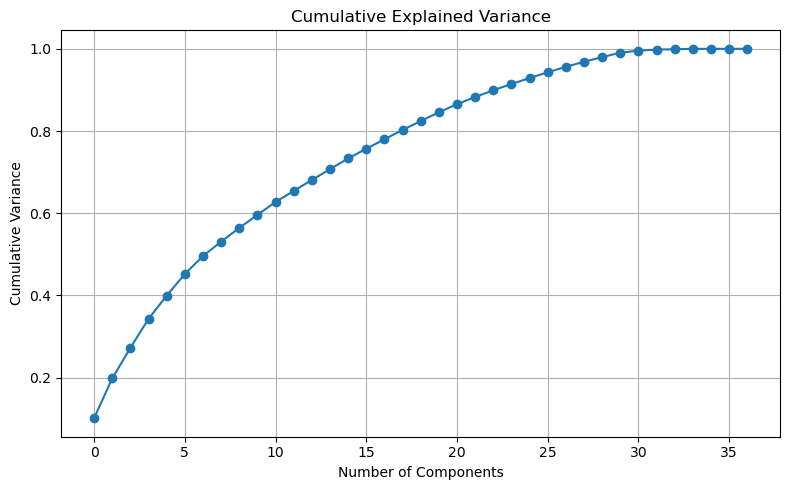

In [19]:
pca_full = PCA()              # keep ALL components
pca_full.fit(X_train_scaled)  # fit on training data only

plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o')
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.grid(True)
plt.tight_layout()
plt.savefig("pca_explained_variance.png", dpi=300)
plt.show()

## Outer Inspection In PCA Space

Potential outliers detected: 21 samples


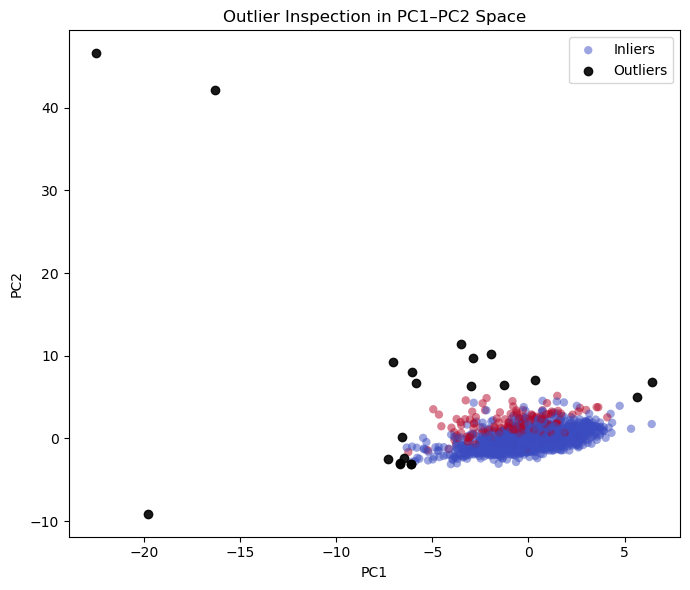

<Figure size 640x480 with 0 Axes>

In [20]:
from numpy.linalg import norm

pc12 = Z_train[:, :2]
center = np.median(pc12, axis=0)
distances = norm(pc12 - center, axis=1)

# Mark top 1% as potential outliers
threshold = np.percentile(distances, 99)
outlier_mask = distances > threshold

print(f"Potential outliers detected: {outlier_mask.sum()} samples")

plt.figure(figsize=(7, 6))
plt.scatter(pc12[~outlier_mask, 0], pc12[~outlier_mask, 1],
            c=y_train[~outlier_mask], cmap="coolwarm", alpha=0.5, edgecolor="none", label="Inliers")
plt.scatter(pc12[outlier_mask, 0], pc12[outlier_mask, 1],
            c="black", alpha=0.9, edgecolor="k", label="Outliers")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Outlier Inspection in PC1–PC2 Space")
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig("logistic_loss.png", dpi=300)

# Logistic Regression (From Scratch)

This section implements logistic regression entirely using NumPy. The goal is to estimate the weight 
vector \( w \) by maximising the Bernoulli log-likelihood using gradient descent, 
while handling class imbalance through weighted loss.

**1. Data preparation**
- A bias column of ones is added to the scaled features.
- Labels are reshaped into column vectors for matrix operations.
- Class weights are computed from training data to counteract imbalance.

**2. Sigmoid function**
- Implements the logistic activation.
- Used to convert linear predictions into probabilities.

**3. Weighted gradient descent**
- Initialises weights to zero.
- Computes predictions.
- Applies class weights: minority samples receive higher influence.
- Computes the gradient of the weighted logistic loss.
- Updates parameters over multiple epochs.
- Stores loss values to verify convergence.

**4. Model evaluation**
- Predicts labels on the test set using a 0.5 threshold.
- Reports accuracy, precision, recall, and F1 score.
- These metrics are essential under severe class imbalance.

**5. Decision boundary visualisation (PCA space)**
- PCA is fitted on the training data to obtain a 2D representation.
- The learned weight vector is projected back into PCA space.
- A probability contour plot shows the logistic decision boundary.
- Training points are overlaid to illustrate linear separability.

This implementation demonstrates the full mathematical pipeline of logistic 
regression: likelihood, gradient descent, class weighting, and geometric 
interpretation in a reduced-dimensional space.

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

## Train/Test Split and Class Weights

In [22]:
X_train_lr = np.hstack([np.ones((X_train_scaled.shape[0], 1)), X_train_scaled])
X_test_lr = np.hstack([np.ones((X_test_scaled.shape[0], 1)), X_test_scaled])

y_train_np = y_train.values.reshape(-1, 1)
y_test_np = y_test.values.reshape(-1, 1)

# Compute class weights
classes = np.unique(y_train)
weights = compute_class_weight("balanced", classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

w0 = class_weight_dict[0]
w1 = class_weight_dict[1]

print("Class weights:", class_weight_dict)

Class weights: {np.float64(0.0): np.float64(0.5491803278688525), np.float64(1.0): np.float64(5.583333333333333)}


## Gradient Descent for Logistic Regression

In [23]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def train_logistic(X, y, lr=0.01, epochs=2000, w0=1, w1=1):
    w = np.zeros((X.shape[1], 1))
    losses = []

    y = y.values.reshape(-1, 1)

    for _ in range(epochs):
        y_hat = sigmoid(X @ w)

        weights = np.where(y == 1, w1, w0)

        grad = (X.T @ (weights * (y_hat - y))) / len(y)
        w -= lr * grad

        loss = -np.mean(
            weights * (y*np.log(y_hat + 1e-10) + (1-y)*np.log(1-y_hat + 1e-10))
        )
        losses.append(loss)

    return w, losses

w_final, losses = train_logistic(
    X_train_lr,
    y_train,
    lr=0.01,
    epochs=2000,
    w0=w0,
    w1=w1
)

## Plot Logistic Loss

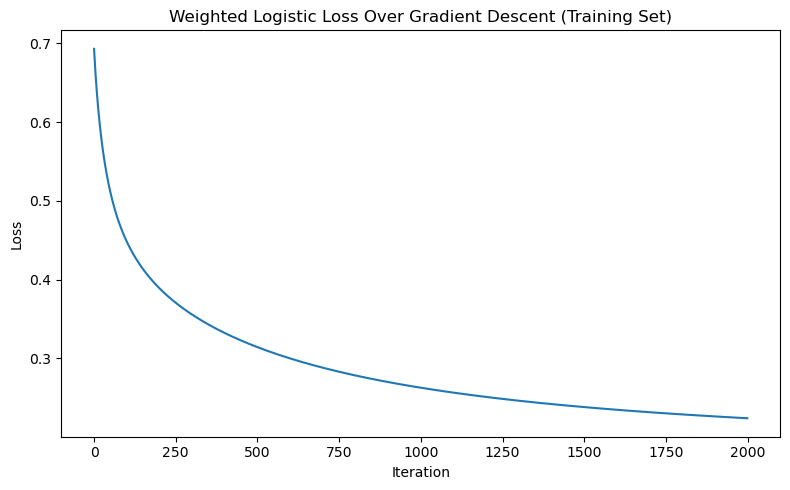

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(losses)
plt.title("Weighted Logistic Loss Over Gradient Descent (Training Set)")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.tight_layout()
plt.savefig("logistic_loss.png", dpi=300)
plt.show()

## Test Set Evaluation

In [25]:
y_pred = (sigmoid(X_test_lr @ w_final) > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.8923076923076924
Precision: 0.45544554455445546
Recall: 0.9787234042553191
F1 Score: 0.6216216216216216


## PCA Projection for Decision Boundary

In [26]:
# PCA (already trained on X_train)
pca = PCA(n_components=2)
Z_train = pca.fit_transform(X_train_scaled)
Z_test = pca.transform(X_test_scaled)
Z = Z_train

# Model parameters
w_vec = w_final[1:].flatten()
b = w_final[0][0]

# Grid in PCA space
x_min, x_max = Z[:,0].min() - 1, Z[:,0].max() + 1
y_min, y_max = Z[:,1].min() - 1, Z[:,1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid_pca = np.c_[xx.ravel(), yy.ravel()]

# Map PCA grid back to original scaled feature space
grid_original = grid_pca @ pca.components_ + pca.mean_
grid_scaled = (grid_original - scaler.mean_) / scaler.scale_

# Predict probabilities
probs = sigmoid(grid_scaled @ w_vec + b).reshape(xx.shape)

## Decision Boundary Plot

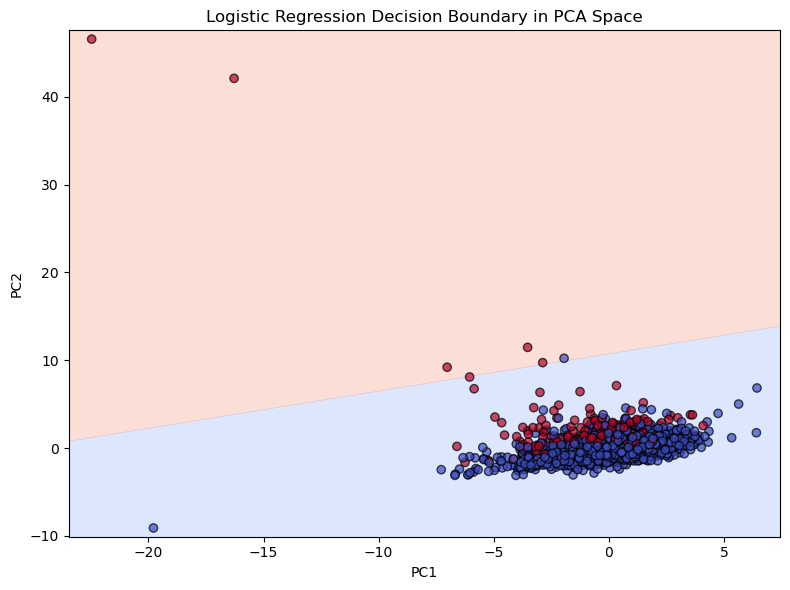

In [27]:
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, probs, levels=[0, 0.5, 1], alpha=0.3, cmap="coolwarm")
plt.scatter(Z[:,0], Z[:,1], c=y_train, cmap="coolwarm", edgecolor="k", alpha=0.7)
plt.title("Logistic Regression Decision Boundary in PCA Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig("logistic_boundary.png", dpi=300)
plt.show()

# K-Nearest Neighbours (KNN)

This section implements KNN as a non‑parametric, distance‑based classifier.  
Unlike logistic regression or SVM, KNN does not learn model parameters; instead, it 
classifies each test point based on the labels of its nearest neighbours in feature space.

**1. Model training and prediction**
- Uses `KNeighborsClassifier` with \( k = 5 \) and distance‑based weighting.
- Trained on the standardised training data.
- Predictions are made on the scaled test set.
- Precision, recall, and F1 score are reported to evaluate minority‑class performance.

**2. PCA projection for visualisation**
- PCA reduces the 38‑dimensional feature space to 2D for geometric interpretation.
- KNN is retrained in PCA space to visualise how neighbourhoods form in a low‑dimensional setting.

**3. Decision boundary in PCA space**
- A dense grid is created across the PCA plane.
- Each grid point is classified using the KNN model trained in PCA space.
- A contour plot visualises the resulting decision regions.
- Training points are overlaid to show how KNN adapts to local geometry.

This section highlights the geometric nature of KNN, its flexibility, and its 
sensitivity to dimensionality and class imbalance.

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA

## Train KNN on Standardised Data

In [29]:
k = 5
knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN F1:", f1_score(y_test, y_pred_knn))
print("KNN Recall:", recall_score(y_test, y_pred_knn))
print("KNN Precision:", precision_score(y_test, y_pred_knn))

KNN F1: 0.4927536231884058
KNN Recall: 0.3617021276595745
KNN Precision: 0.7727272727272727


## PCA for Visualisation (2D)

In [30]:
pca = PCA(n_components=2)
Z_train = pca.fit_transform(X_train_scaled)
Z_test  = pca.transform(X_test_scaled)

## KNN Decision Boundary in PCA Space

In [31]:
knn_pca = KNeighborsClassifier(n_neighbors=k, weights='distance')
knn_pca.fit(Z_train, y_train)

# Grid for decision boundary
x_min, x_max = Z_train[:,0].min() - 1, Z_train[:,0].max() + 1
y_min, y_max = Z_train[:,1].min() - 1, Z_train[:,1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
grid_pred = knn_pca.predict(grid).reshape(xx.shape)

## Plot Decision Boundary

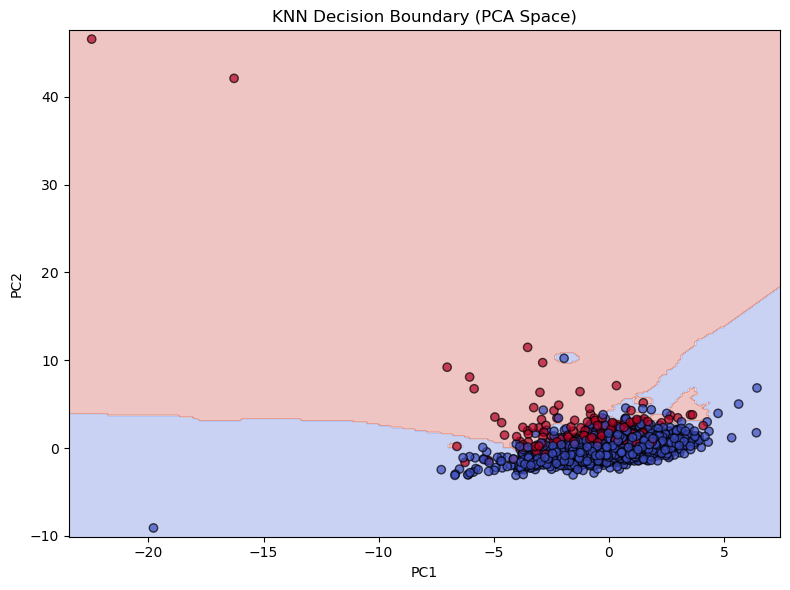

In [32]:
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, grid_pred, alpha=0.3, cmap="coolwarm")

# Plot training points
plt.scatter(
    Z_train[:,0],
    Z_train[:,1],
    c=y_train,
    cmap="coolwarm",
    edgecolor="k",
    alpha=0.7
)

plt.title("KNN Decision Boundary (PCA Space)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig("knn_boundary.png", dpi=300)
plt.show()

# Support Vector Machine (SVM)

This section implements a linear Support Vector Machine using scikit‑learn.  
The aim is to analyse the margin‑based geometric classifier
and visualise its separating hyperplane in PCA space.

**1. Model training and prediction**
- Uses a **linear SVM** (`kernel="linear"`) to match the mathematical formulation.
- `class_weight="balanced"` compensates for the severe class imbalance.
- The model is trained on the standardised training data.
- Accuracy, precision, recall, and F1 score are computed on the test set.

**2. PCA projection for geometric interpretation**
- PCA reduces the 38‑dimensional feature space to 2D.
- Both the training data and the SVM’s support vectors are projected into this space.
- Support vectors are the critical points that define the margin.

**3. Decision boundary visualisation**
- A dense grid is created across the PCA plane.
- Each grid point is mapped back to the original scaled feature space.
- The trained SVM predicts labels for the grid to form decision regions.
- The contour plot shows the linear separating hyperplane in PCA space.
- Support vectors are highlighted to illustrate their geometric role.

This section demonstrates the margin‑maximising nature of SVMs, their robustness 
under class imbalance, and their geometric behaviour in a reduced‑dimensional 
representation of the hematological dataset.

In [33]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.decomposition import PCA

## Train Linear SVM

In [34]:
svm = SVC(kernel="linear", class_weight="balanced")
svm.fit(X_train_scaled, y_train)

# Predictions
y_pred_svm = svm.predict(X_test_scaled)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM Precision:", precision_score(y_test, y_pred_svm))
print("SVM Recall:", recall_score(y_test, y_pred_svm))
print("SVM F1 Score:", f1_score(y_test, y_pred_svm))

SVM Accuracy: 0.9211538461538461
SVM Precision: 0.5357142857142857
SVM Recall: 0.9574468085106383
SVM F1 Score: 0.6870229007633588


## PCA Projection for Visualisation

In [35]:
pca = PCA(n_components=2)
Z_train = pca.fit_transform(X_train_scaled)
Z_test  = pca.transform(X_test_scaled)

## Decision Boundary Grid in PCA Space

In [36]:
support_vectors_scaled = svm.support_vectors_
Z_support = pca.transform(support_vectors_scaled)

# Grid for decision boundary
x_min, x_max = Z_train[:,0].min() - 1, Z_train[:,0].max() + 1
y_min, y_max = Z_train[:,1].min() - 1, Z_train[:,1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid_pca = np.c_[xx.ravel(), yy.ravel()]

# Map PCA grid back to original scaled feature space
grid_original = grid_pca @ pca.components_ + pca.mean_

# Predict using SVM
grid_pred = svm.predict(grid_original).reshape(xx.shape)

## Predict on Grid + Plot Boundary

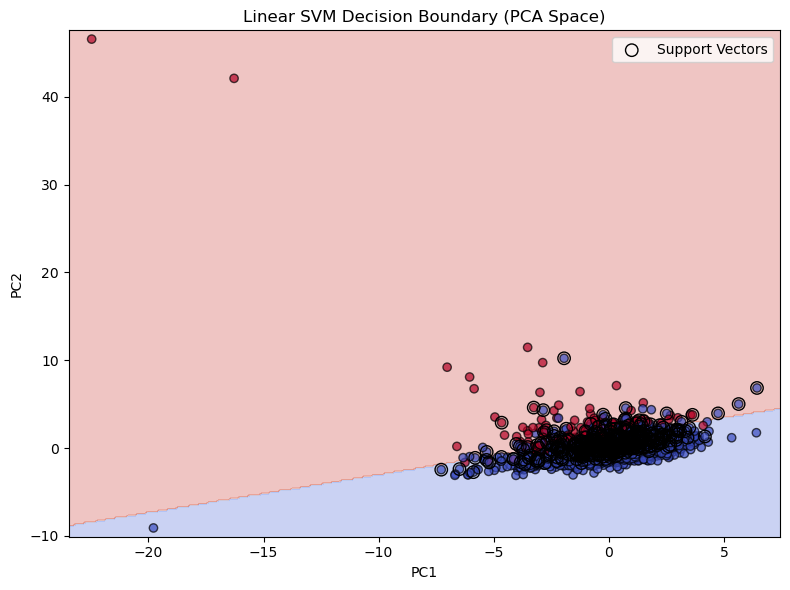

In [37]:
plt.figure(figsize=(8, 6))

# Decision regions
plt.contourf(xx, yy, grid_pred, alpha=0.3, cmap="coolwarm")

# Data points in PCA space
plt.scatter(Z_train[:,0], Z_train[:,1],
            c=y_train, cmap="coolwarm",
            edgecolor="k", alpha=0.7)

# Support vectors highlighted
plt.scatter(Z_support[:,0], Z_support[:,1],
            s=80, facecolors='none', edgecolors='black',
            label="Support Vectors")

plt.title("Linear SVM Decision Boundary (PCA Space)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.savefig("svm_boundary.png", dpi=300)
plt.show()

# Comparative Analysis

This section compares the behaviour of Logistic Regression, KNN, and SVM using 
geometric and statistical diagnostics. The aim is to relate each model’s 
mathematical assumptions to its empirical behaviour on the dataset.

---

### **1. Pairwise Distance Distribution (KNN Sensitivity)**  
- Computes all pairwise Euclidean distances in the **training set**.  
- Flattens the upper triangle of the distance matrix to analyse the distribution.  
- A histogram reveals **distance concentration**, a key symptom of the 
  curse of dimensionality.  
- When distances become similar, KNN struggles to form meaningful neighbourhoods.

---

### **2. Logistic Regression vs SVM Decision Boundaries (PCA Space)**  
- PCA reduces the 38‑dimensional space to 2D for geometric interpretation.  
- The learned weight vectors from Logistic Regression and SVM are projected into PCA space.  
- Decision boundaries are computed analytically from the projected weights.  
- The plot shows:  
  - Logistic Regression → probability‑based linear separator  
  - SVM → margin‑maximising separator  
- This visual comparison highlights how different optimisation objectives 
  produce different hyperplanes.

---

### **3. Probability vs Margin Score Distributions**  
- Logistic Regression outputs **probabilities** in \([0,1]\).  
- SVM outputs **signed distances** from the hyperplane (unbounded).  
- Histograms of both outputs illustrate:  
  - Logistic Regression spreads samples across the probability range.  
  - SVM produces sharper separation due to margin maximisation.  
- This comparison links the models’ objective functions to their output geometry.

---

Together, these diagnostics provide a mathematical and geometric comparison of the 
three classifiers, reinforcing the theoretical analysis presented in the report.

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances

## Pairwise Distance Distribution (KNN Sensitivity)

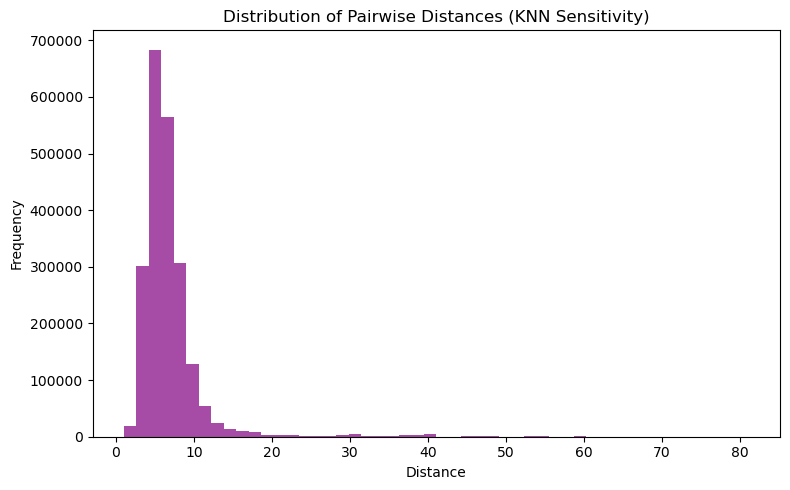

In [39]:
# Compute pairwise distances on training data
dists = pairwise_distances(X_train_scaled)

# Flatten upper triangle
flat = dists[np.triu_indices_from(dists, k=1)]

plt.figure(figsize=(8,5))
plt.hist(flat, bins=50, color='purple', alpha=0.7)
plt.title("Distribution of Pairwise Distances (KNN Sensitivity)")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("knn_distance_distribution.png", dpi=300)
plt.show()

## Logistic vs SVM Decision Boundaries in PCA Space

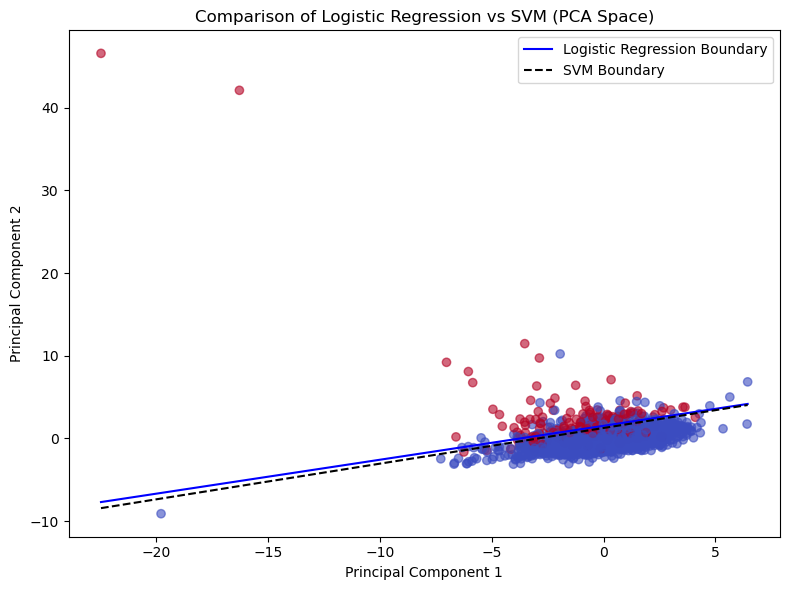

<Figure size 640x480 with 0 Axes>

In [40]:
pca = PCA(n_components=2)
Z_train = pca.fit_transform(X_train_scaled)

# Ensure label alignment (critical for correct plotting)
y_plot = y_train.values

# Logistic Regression weights (from scratch model)
w_log = w_final[1:].flatten()
b_log = w_final[0]

# SVM weights (linear kernel)
w_svm = svm.coef_.flatten()
b_svm = svm.intercept_[0]

# Project weight vectors into PCA space
w_log_pca = pca.components_ @ w_log
w_svm_pca = pca.components_ @ w_svm

# 4. Create grid for decision boundary plotting
xx = np.linspace(Z_train[:, 0].min(), Z_train[:, 0].max(), 200)

# small numerical stability term
eps = 1e-8

# Logistic decision boundary in PCA space
yy_log = -(w_log_pca[0] / (w_log_pca[1] + eps)) * xx - b_log / (w_log_pca[1] + eps)

# SVM decision boundary in PCA space
yy_svm = -(w_svm_pca[0] / (w_svm_pca[1] + eps)) * xx - b_svm / (w_svm_pca[1] + eps)

# Plot data + decision boundaries
plt.figure(figsize=(8, 6))

# PCA scatter plot (training data only)
plt.scatter(
    Z_train[:, 0],
    Z_train[:, 1],
    c=y_plot.astype(int),
    cmap="coolwarm",
    alpha=0.6
)

# Logistic regression boundary
plt.plot(xx, yy_log, label="Logistic Regression Boundary", color="blue")

# SVM boundary
plt.plot(xx, yy_svm, label="SVM Boundary", color="black", linestyle="--")

# Final plot formatting
plt.title("Comparison of Logistic Regression vs SVM (PCA Space)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig("logistic_loss.png", dpi=300)

## Probability vs Margin Score Distributions

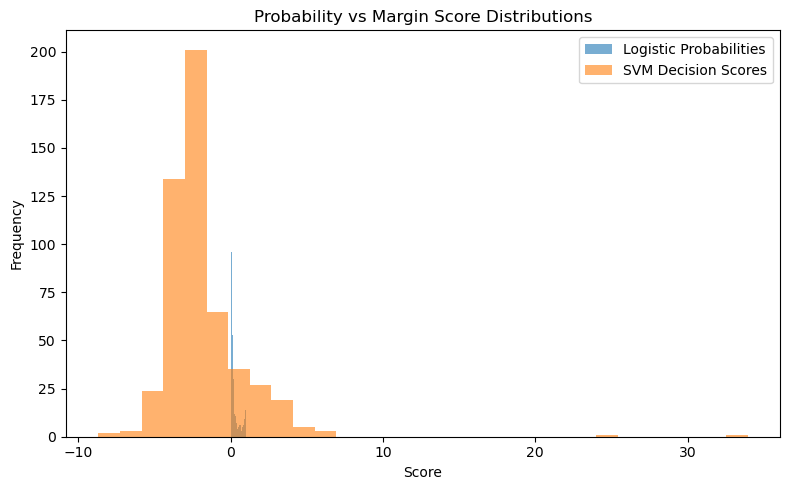

In [41]:
log_probs = sigmoid(X_test_lr @ w_final).flatten()

# ------------------------------
# SVM outputs
# ------------------------------
# decision_function gives signed distance from hyperplane
# (not probability, but margin score)
svm_scores = svm.decision_function(X_test_scaled)

# Plot distributions
plt.figure(figsize=(8, 5))

# Logistic regression: bounded [0,1]
plt.hist(log_probs, bins=30, alpha=0.6, label="Logistic Probabilities")

# SVM: unbounded margin scores
plt.hist(svm_scores, bins=30, alpha=0.6, label="SVM Decision Scores")

plt.title("Probability vs Margin Score Distributions")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.savefig("probability_vs_margin.png", dpi=300)
plt.show()